<a href="https://colab.research.google.com/github/arashhadadex/Data-visualization/blob/main/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraris

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# If you use %matplitlib inline, you can skip plt.show() later

In [22]:
%matplotlib inline

# Downlading and reading dataset
## Kaggle: https://www.kaggle.com/datasets/camnugent/california-housing-prices
## GitHub: https://github.com/ageron/handson-ml/blob/master/datasets/housing/housing.csv

In [3]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Checking DataFrame shape and Column data types

In [5]:
print(df.shape)

(20640, 10)


In [4]:
print(df.dtypes)

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


# Printing the first 5 rows of DataFrame

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Check how many missing values each feature has

In [5]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


# Plotting the histogram to check your target variable's distribution
## Median House Value
## df.plot(kind='hist')

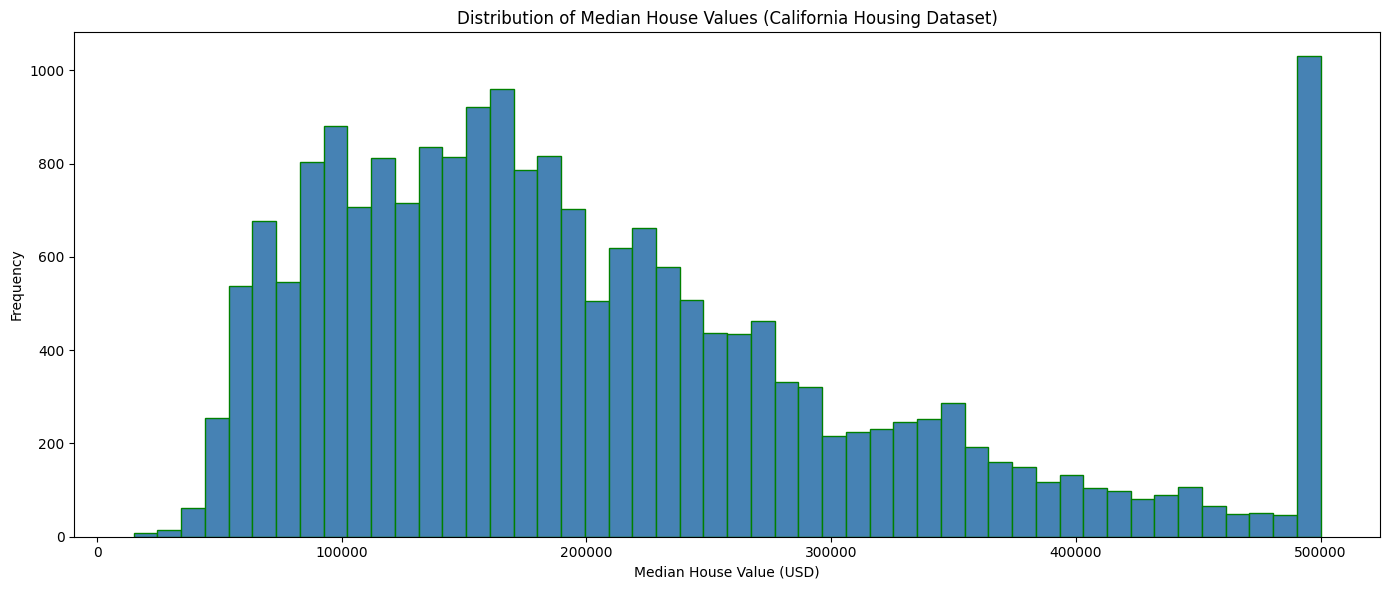

In [7]:
df['median_house_value'].plot(
    kind='hist',
    bins=50,
    figsize=(14, 6),
    color='steelblue',
    edgecolor='green',
    title='Distribution of Median House Values (California Housing Dataset)'
)
plt.xlabel('Median House Value (USD)')
plt.ylabel('Frequency')
plt.tight_layout() # automatically adjusts subplot params so that the subplot(s) fits in to the figure area
plt.show()

# Printing all numeric columns at once
## df.hist()

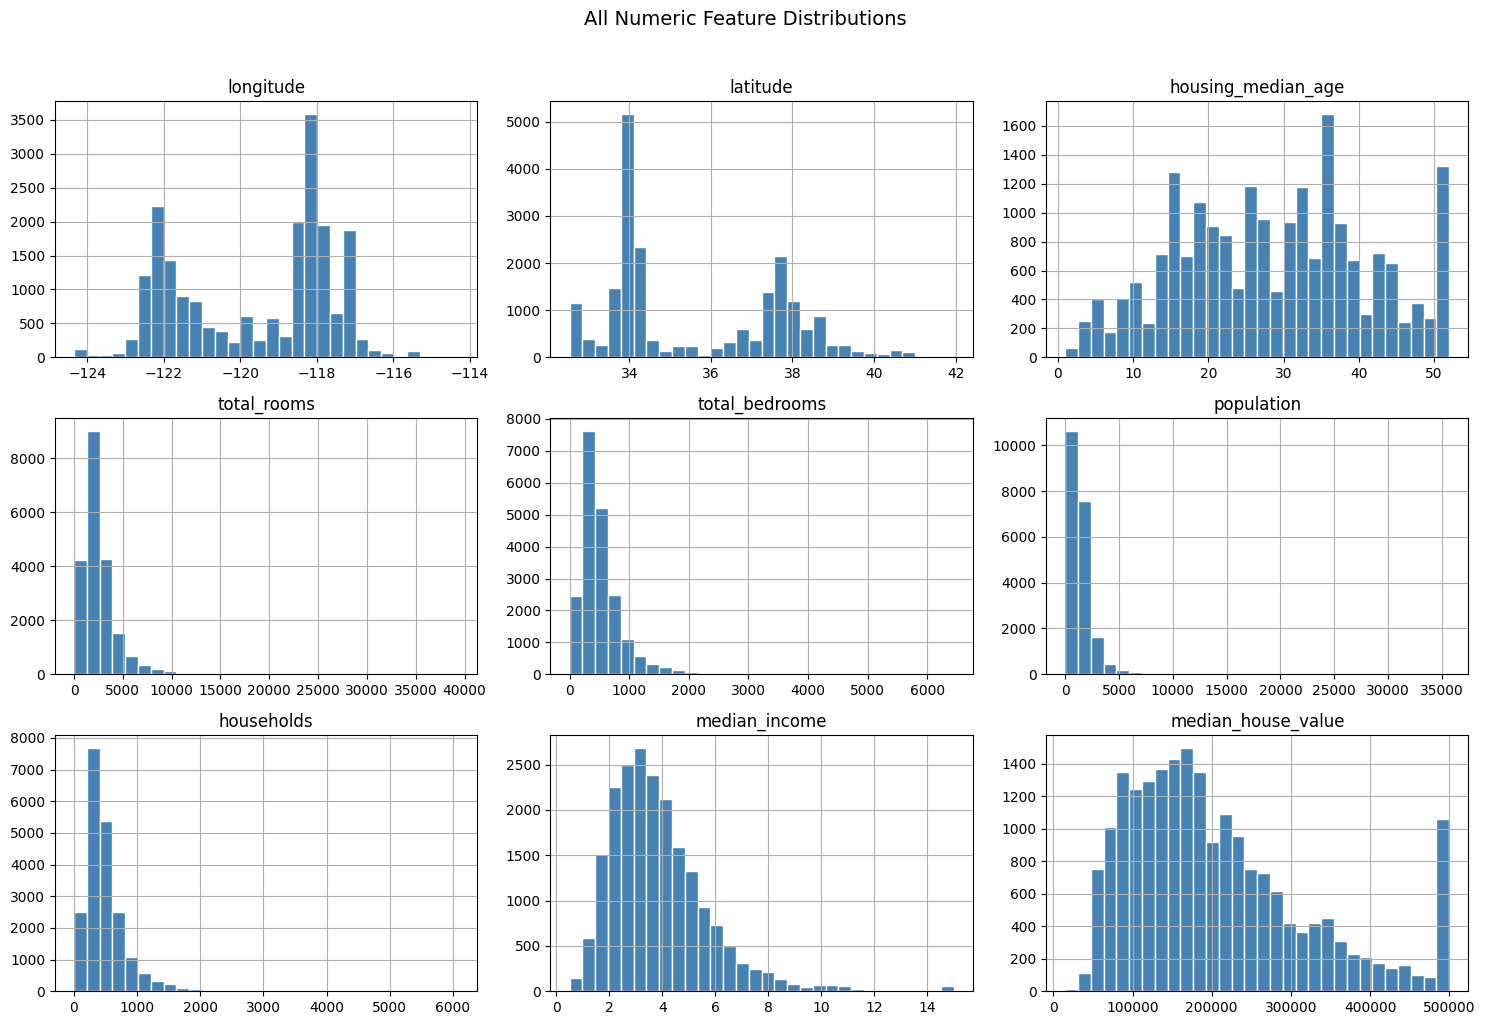

In [9]:
df.hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='white')
plt.suptitle('All Numeric Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Sorting values and plotting
## Best for continuous values like stock price or age

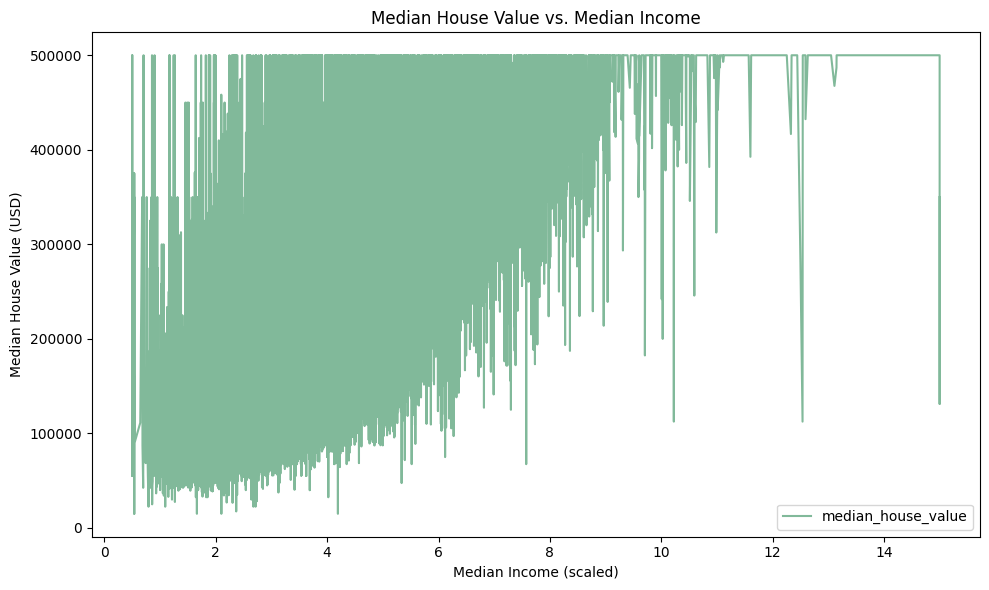

In [11]:
# the default argument for .sort_values() is ascending
df_sorted = df[['median_income', 'median_house_value']].sort_values('median_income')

df_sorted.plot(
    x='median_income',
    y='median_house_value',
    kind='line',
    figsize=(10, 6),
    color='seagreen',
    alpha=0.6,
    title='Median House Value vs. Median Income'
)
plt.xlabel('Median Income (scaled)')
plt.ylabel('Median House Value (USD)')
plt.tight_layout()
plt.show()

# Another option is to bin the income and plot the mean to see the actual trend:

/tmp/ipykernel_638/3754341448.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('income_bin')['median_house_value'].mean().plot(


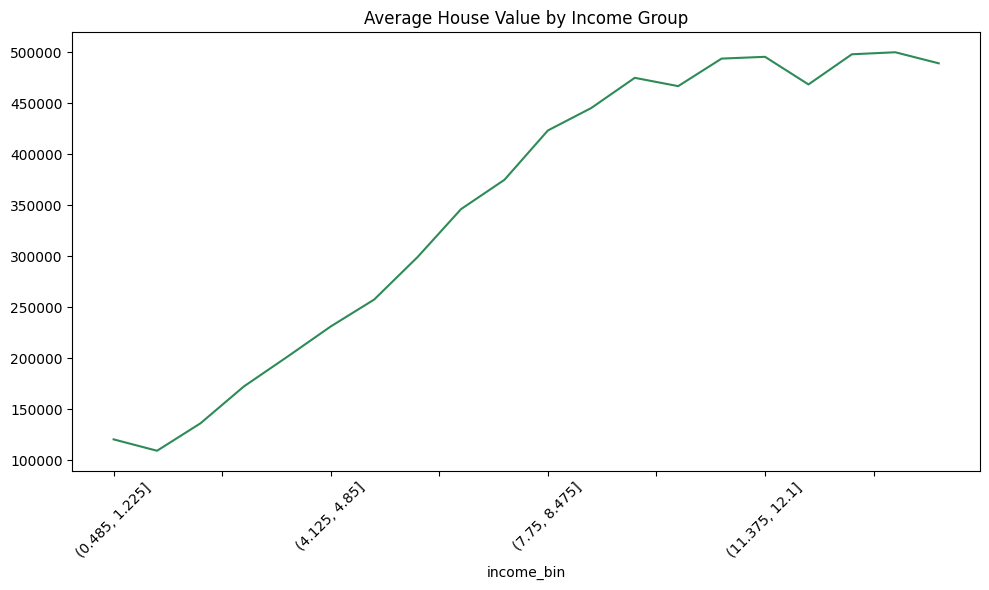

In [13]:
df['income_bin'] = pd.cut(df['median_income'], bins=20)
df.groupby('income_bin')['median_house_value'].mean().plot(
    kind='line', figsize=(10, 6), color='seagreen',
    title='Average House Value by Income Group'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar plot
## df.plot(kind='bar')
## The right tool for comparing a numeric metric across discrete categories

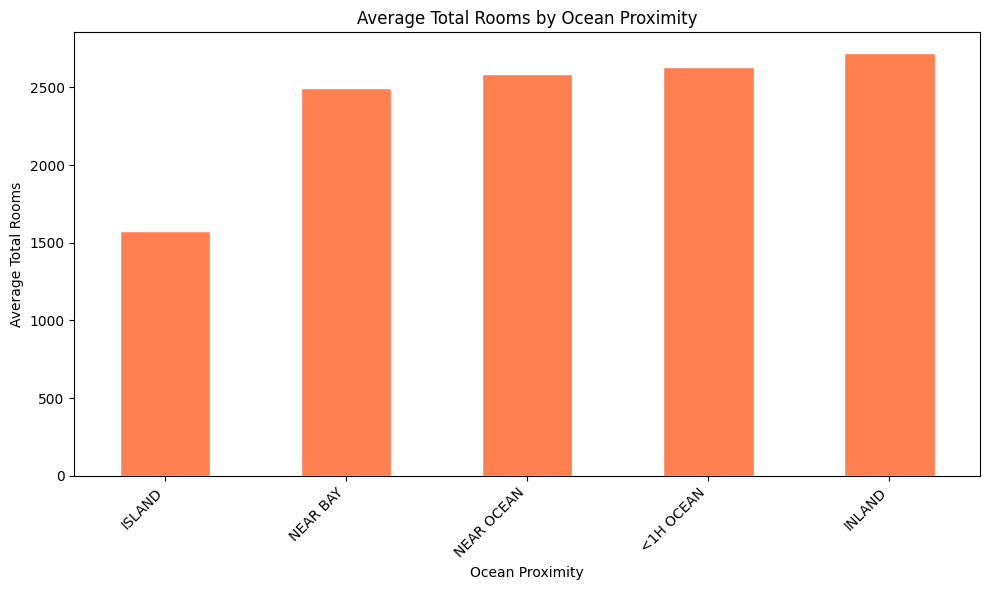

In [15]:
df.groupby('ocean_proximity')['total_rooms'].mean().sort_values().plot(
    kind='bar',
    color='coral',
    edgecolor='white',
    figsize=(10, 6),
    title='Average Total Rooms by Ocean Proximity'
)
plt.xlabel('Ocean Proximity')
plt.ylabel('Average Total Rooms')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ISLAND properties tend to stand out, with a very small sample size and extreme values.

In [13]:
print(df['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


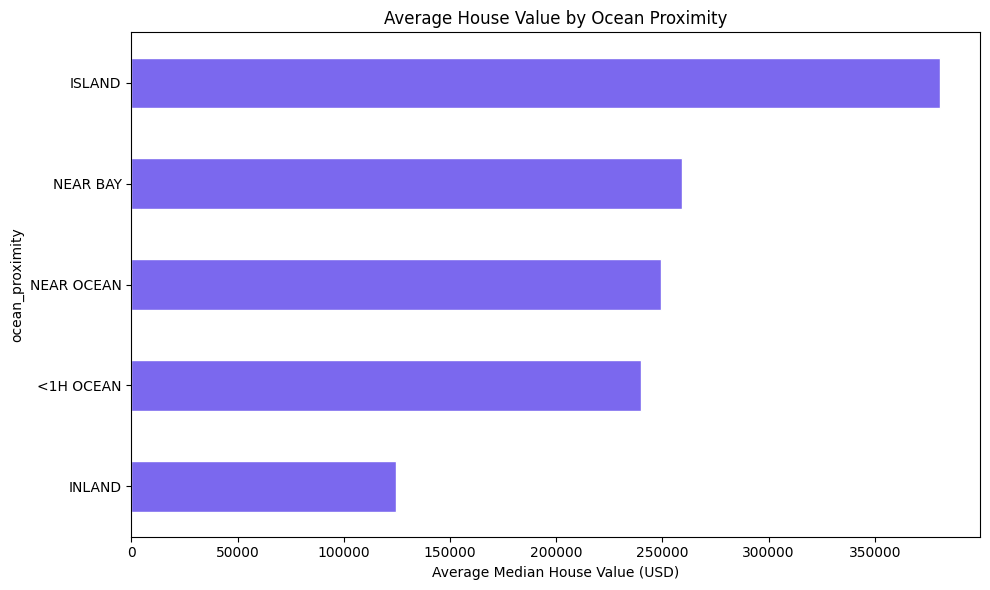

In [14]:
df.groupby('ocean_proximity')['median_house_value'].mean().sort_values().plot(
    kind='barh',
    color='mediumslateblue',
    edgecolor='white',
    figsize=(10, 6),
    title='Average House Value by Ocean Proximity'
)
plt.xlabel('Average Median House Value (USD)')
plt.tight_layout()
plt.show()

# Correlation Heat Map
## df.corr()
## A correlation heatmap shows the linear relationship between every pair of numeric features in a single view.

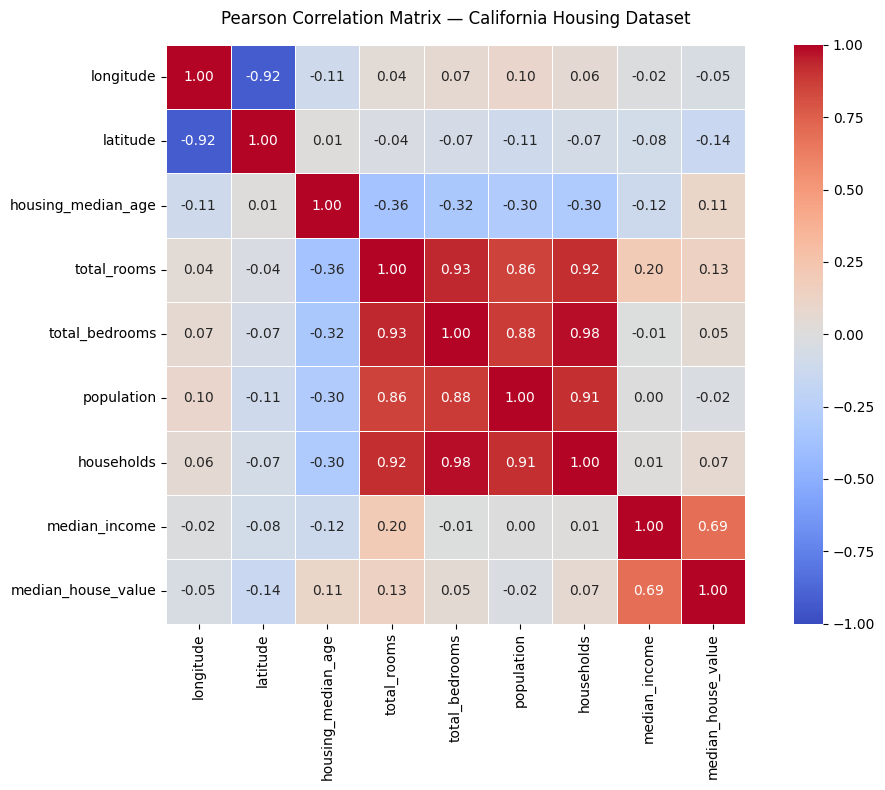

In [15]:
# Drop non-numeric columns before computing correlation
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Compute the Pearson correlation matrix
corr_matrix = df_numeric.corr()

# Plot with Seaborn
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values in each cell
    fmt='.2f',            # round to 2 decimal places
    cmap='coolwarm',      # diverging colormap: red = positive, blue = negative
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1       # fix color scale to [-1, 1] for accurate interpretation
)
plt.title('Pearson Correlation Matrix — California Housing Dataset', pad=15)
plt.tight_layout()
plt.show()

# Scatter plot
## df.plot(kind='scatter')
## Scatter plots reveal what line plots cannot: the actual density and spread of your data points, and outliers that a mean or trend line would hide.

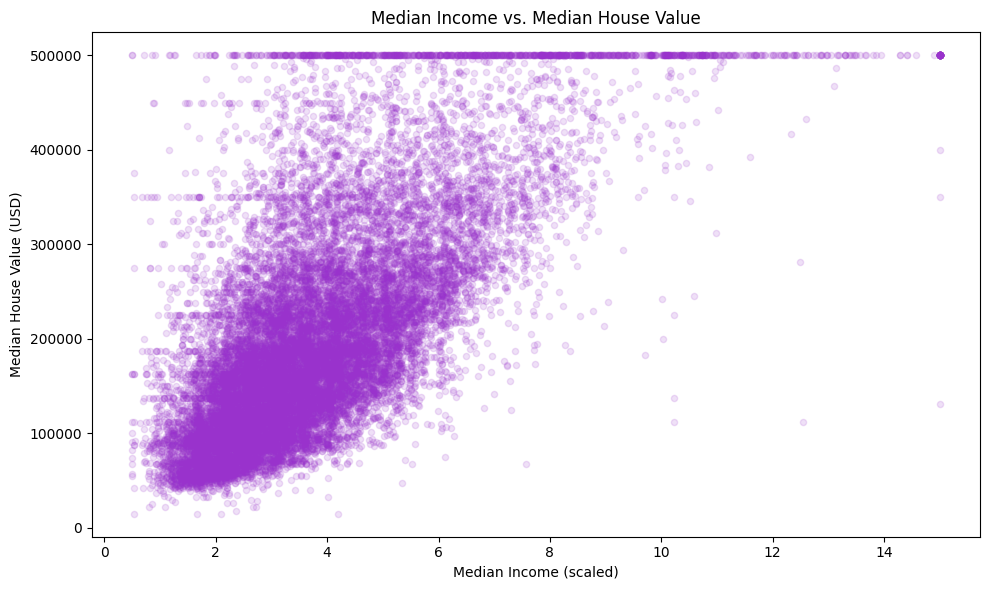

In [16]:
df.plot(
    kind='scatter',
    x='median_income',
    y='median_house_value',
    alpha=0.15,           # low alpha reveals density clusters in dense regions
    color='darkorchid',
    figsize=(10, 6),
    title='Median Income vs. Median House Value'
)
plt.xlabel('Median Income (scaled)')
plt.ylabel('Median House Value (USD)')
plt.tight_layout()
plt.show()

# geographic dimension with color-coded scatter

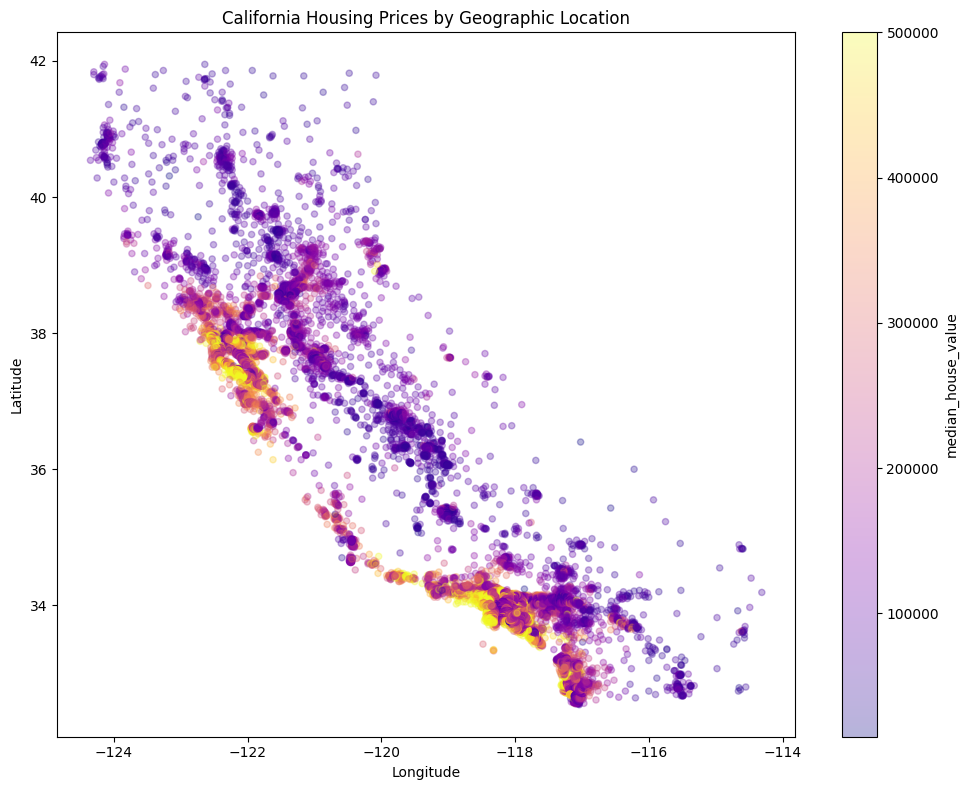

In [17]:
# Color-code by median house value to create a geographic heat map
df.plot(
    kind='scatter',
    x='longitude',
    y='latitude',
    alpha=0.3,
    figsize=(10, 8),
    c='median_house_value',   # color points by house value
    cmap='plasma',
    colorbar=True,
    title='California Housing Prices by Geographic Location'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

# Pairplot with seaborn
## A pair plot generates a matrix of scatter plots for every combination of selected features, making it useful for spotting correlated pairs and non-linear relationships at a glance.

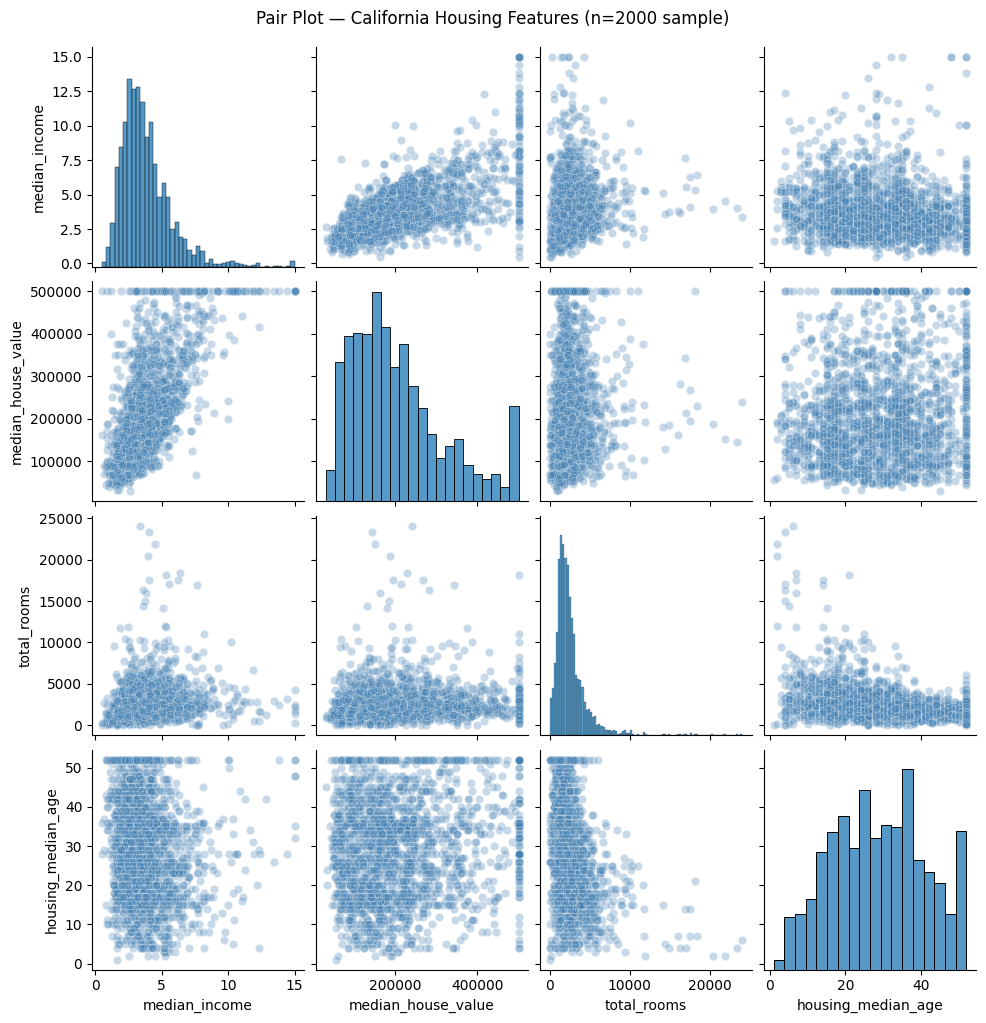

In [16]:
# Subset to 4 features and sample rows — pairplot on 20K rows is slow
sample_df = df[['median_income', 'median_house_value', 'total_rooms', 'housing_median_age']].sample(2000, random_state=42)

pair_grid = sns.pairplot(
    sample_df,
    diag_kind='hist',       # kernel density on diagonal instead of histogram
    plot_kws={'alpha': 0.3, 'color': 'steelblue'}
)
pair_grid.fig.suptitle('Pair Plot — California Housing Features (n=2000 sample)', y=1.02)
plt.show()

# Box plot to finding outliers
## df.boxplot()
## Box plots show the median, interquartile range (IQR), and outliers in one compact view, which is useful for comparing distributions across categories.

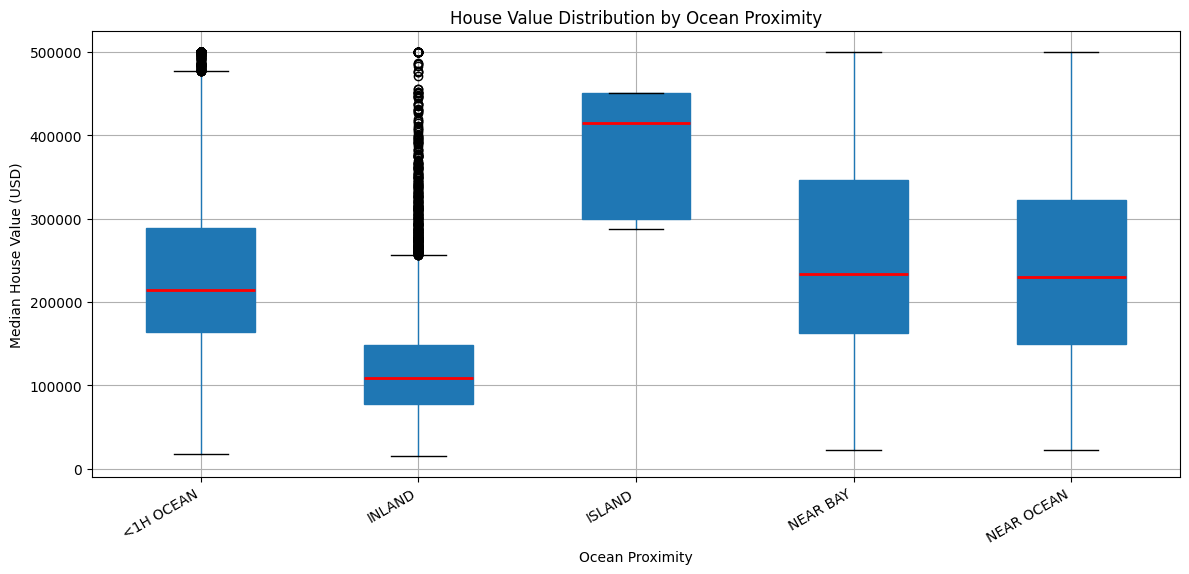

In [19]:
# Compare house value distribution across ocean proximity categories
df.boxplot(
    column='median_house_value',
    by='ocean_proximity',
    figsize=(12, 6),
    patch_artist=True,
    medianprops={'color': 'red', 'linewidth': 2}
)
plt.title('House Value Distribution by Ocean Proximity')
plt.suptitle('')          # suppress pandas auto-generated subtitle
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Plotly
## px.scatter()
## Interactive charts (zoom, hover, filter)

In [20]:
# pip install plotly
import plotly.express as px

fig = px.scatter(
    df.sample(5000, random_state=42),
    x='median_income',
    y='median_house_value',
    color='ocean_proximity',
    opacity=0.5,
    title='Interactive: Income vs. House Value by Ocean Proximity',
    labels={
        'median_income': 'Median Income (scaled)',
        'median_house_value': 'Median House Value (USD)'
    }
)
fig.show()

# Saving image

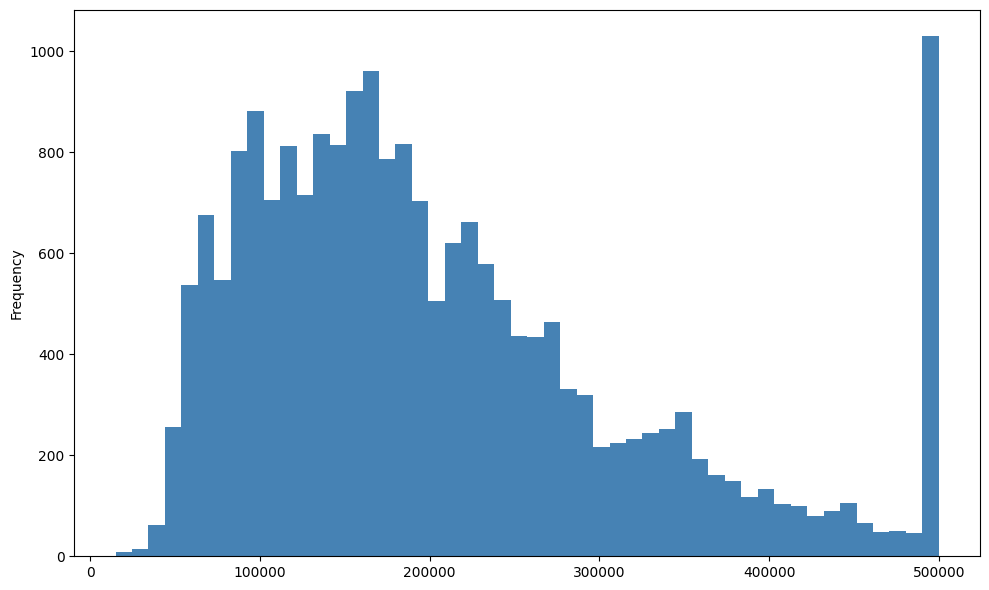

In [21]:
# Save at high resolution for reports
df['median_house_value'].plot(kind='hist', bins=50, figsize=(10, 6), color='steelblue')
plt.tight_layout()
plt.savefig('house_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()